# 🚕 Uber Fare Prediction
**Dataset Source:** [Kaggle - Uber Fares Dataset](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset)

This notebook covers:
- Data Loading & Type Conversion
- Exploratory Data Analysis (EDA)
- Data Preprocessing & Feature Engineering
- Outlier Treatment
- Univariate & Bivariate Analysis with Visualizations
- Feature Scaling
- Model Building: Linear Regression & Decision Tree Regressor

---
## 📦 Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, asin
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 2: Load Data

In [3]:
# Load CSV file into pandas DataFrame
fare_data = pd.read_csv('uber.csv')
fare_data.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


---
## 🔍 Step 3: Data Exploration

In [4]:
# Check data types
print("📌 Data Types:")
print(fare_data.dtypes)

📌 Data Types:
Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


In [5]:
# Convert numeric columns to float and datetime column
fare_data[['fare_amount', 'pickup_longitude', 'pickup_latitude',
           'dropoff_longitude', 'dropoff_latitude', 'passenger_count']] = \
    fare_data[['fare_amount', 'pickup_longitude', 'pickup_latitude',
               'dropoff_longitude', 'dropoff_latitude', 'passenger_count']].astype(float)

fare_data['pickup_datetime'] = pd.to_datetime(fare_data['pickup_datetime'])

print("✅ Updated Data Types:")
print(fare_data.dtypes)

✅ Updated Data Types:
Unnamed: 0                         int64
key                               object
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                  float64
dtype: object


In [6]:
# Dataset info: shape, nulls, types
print("📊 Dataset Info:")
fare_data.info()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         200000 non-null  int64              
 1   key                200000 non-null  object             
 2   fare_amount        200000 non-null  float64            
 3   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 4   pickup_longitude   200000 non-null  float64            
 5   pickup_latitude    200000 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    200000 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(6), int64(1), object(1)
memory usage: 13.7+ MB


In [7]:
# Check unique values in each column
print("🔢 Unique Values per Column:")
print(fare_data.nunique())

🔢 Unique Values per Column:
Unnamed: 0           200000
key                  200000
fare_amount            1244
pickup_datetime      196629
pickup_longitude      71066
pickup_latitude       83835
dropoff_longitude     76894
dropoff_latitude      90585
passenger_count           8
dtype: int64


> **Observations:**
> - `dropoff_longitude` and `dropoff_latitude` have missing values → will be dropped
> - Mix of numerical and categorical variables:
>   - **Numerical:** pickup/dropoff coordinates, fare_amount
>   - **Categorical:** passenger_count
> - **Target variable:** `fare_amount`

---
## 🧹 Step 4: Data Cleaning

In [8]:
# Work on a copy
data = fare_data.copy()

# Drop unnecessary columns and missing rows
data = data.drop(['Unnamed: 0', 'key'], axis=1, errors='ignore')
data.dropna(axis=0, inplace=True)

print(f"✅ Shape after cleaning: {data.shape}")
data.describe().T

✅ Shape after cleaning: (199999, 7)


,count,mean,std,min,25%,50%,75%,max
fare_amount,199999.0,11.359892,9.901760,-52.000000,6.000000,8.500000,12.500000,499.000000
pickup_longitude,199999.0,-72.527631,11.437815,-1340.648410,-73.992065,-73.981823,-73.967154,57.418457
pickup_latitude,199999.0,39.935881,7.720558,-74.015515,40.734796,40.752592,40.767158,1644.421482
dropoff_longitude,199999.0,-72.525292,13.117408,-3356.666300,-73.991407,-73.980093,-73.963658,1153.572603
dropoff_latitude,199999.0,39.923890,6.794829,-881.985513,40.733823,40.753042,40.768001,872.697628
passenger_count,199999.0,1.684543,1.385995,0.000000,1.000000,1.000000,2.000000,208.000000


> **Possible Outliers:**
> - `fare_amount` ranges from -52 to 499 — negative fares are unrealistic. Minimum base fare = $2.5
> - `passenger_count` has a max of 208 — impossible. Maximum to be set at 5

---
## 🔗 Step 5: Correlation Analysis

In [9]:
# Identify correlations
print("📌 Correlation Matrix:")
data.corr(numeric_only=True)

📌 Correlation Matrix:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
fare_amount,1.000000,0.010458,-0.008482,0.008986,-0.011014,0.010158
pickup_longitude,0.010458,1.000000,-0.816461,0.833026,-0.846324,-0.000415
pickup_latitude,-0.008482,-0.816461,1.000000,-0.774787,0.702367,-0.001559
dropoff_longitude,0.008986,0.833026,-0.774787,1.000000,-0.917010,0.000033
dropoff_latitude,-0.011014,-0.846324,0.702367,-0.917010,1.000000,-0.000659
passenger_count,0.010158,-0.000415,-0.001559,0.000033,-0.000659,1.000000


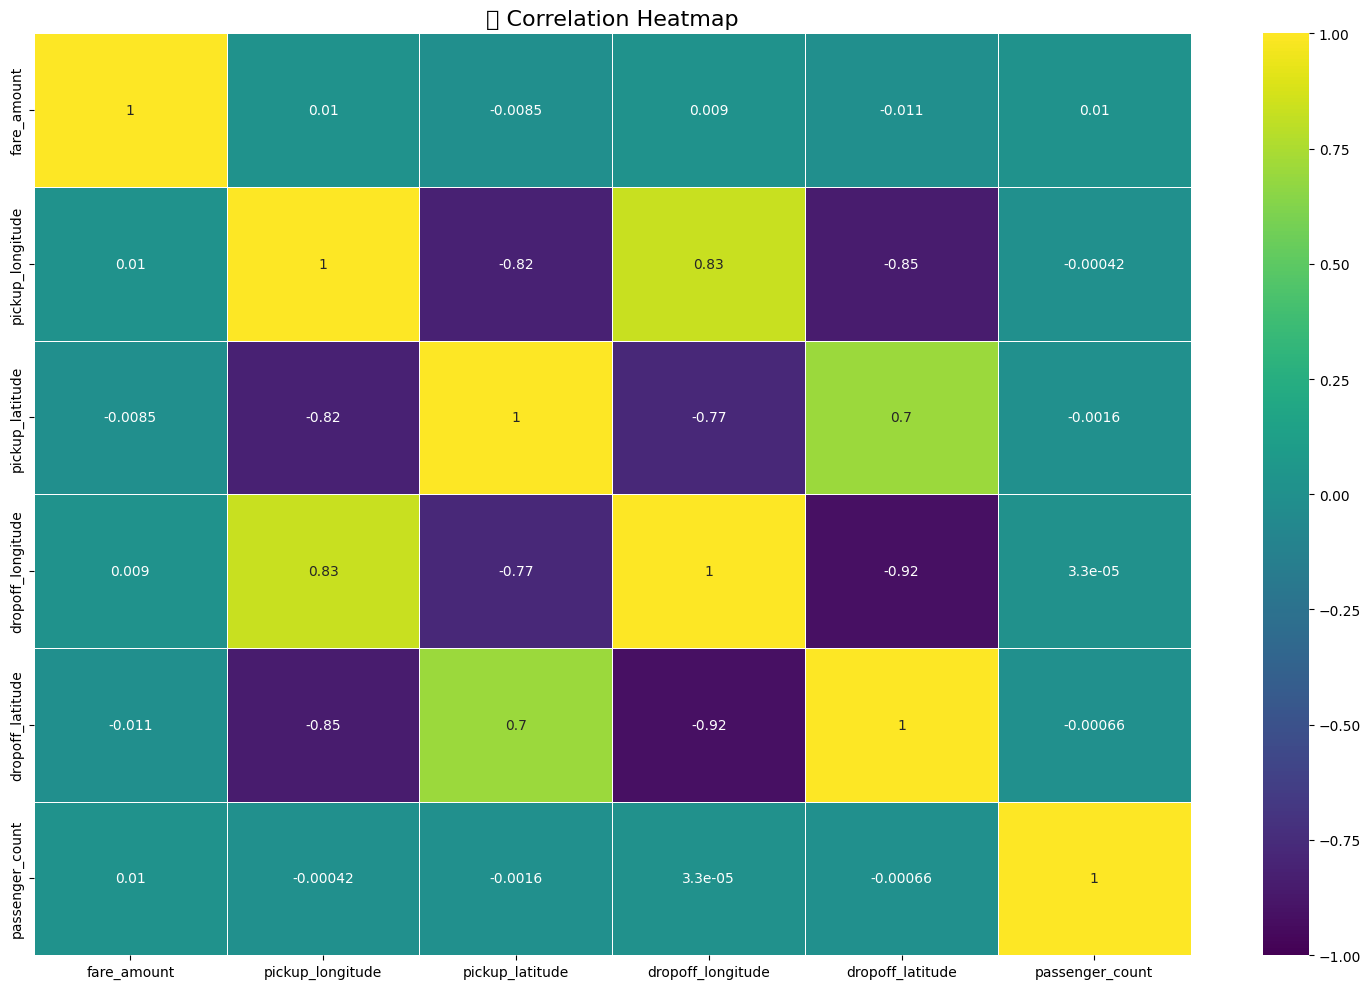

In [ ]:
# Plot correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidths=0.5,
            vmin=-1, vmax=1, fmt='.2g', cmap='viridis')
plt.title('🔥 Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

> **Observation:** High correlation is observed between the geo-spatial data points, which was expected.
> There is no need to drop any of the independent variables at this stage.

---
## 📐 Step 6: Feature Engineering — Haversine Distance

In [10]:
# Define Haversine distance formula
def distance(longitude1, latitude1, longitude2, latitude2):
    travel_dist = []
    for pos in range(len(longitude1)):
        long1, lati1, long2, lati2 = map(radians,
            [longitude1[pos], latitude1[pos], longitude2[pos], latitude2[pos]])
        dist_long = long2 - long1
        dist_lati = lati2 - lati1
        a = sin(dist_lati/2)**2 + cos(lati1) * cos(lati2) * sin(dist_long/2)**2
        c = 2 * asin(sqrt(a)) * 6371   
        travel_dist.append(c)
    return travel_dist

# Calculate distance for each row
data['distance_travelled'] = distance(
    data['pickup_longitude'].to_numpy(),
    data['pickup_latitude'].to_numpy(),
    data['dropoff_longitude'].to_numpy(),
    data['dropoff_latitude'].to_numpy()
)

print("✅ Distance column added!")
data[['distance_travelled']].describe()

✅ Distance column added!


,distance_travelled
count,199999.000000
mean,20.855350
std,382.964642
min,0.000000
25%,1.215222
50%,2.120992
75%,3.875169
max,16409.239135


In [11]:
# Extract date-time features from pickup_datetime
data['pickup_datetime'] = pd.to_datetime(data['pickup_datetime'])

data['date']           = data['pickup_datetime'].dt.date
data['month']          = data['pickup_datetime'].dt.month
data['year']           = data['pickup_datetime'].dt.year
data['day_of_the_week']= data['pickup_datetime'].dt.weekday
data['day_name']       = data['pickup_datetime'].dt.day_name()
data['pickup_time']    = data['pickup_datetime'].dt.time
data['pickup_hour']    = data['pickup_datetime'].dt.hour

print("✅ Date-time features extracted!")
data.head(3)

✅ Date-time features extracted!


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_travelled,date,month,year,day_of_the_week,day_name,pickup_time,pickup_hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1.0,1.683323,2015-05-07,5,2015,3,Thursday,19:52:06,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1.0,2.457590,2009-07-17,7,2009,4,Friday,20:04:56,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1.0,5.036377,2009-08-24,8,2009,0,Monday,21:45:00,21


---
## 🚫 Step 7: Outlier Treatment

In [12]:
# Apply outlier filters
data.drop(data[data['passenger_count'] > 5].index, inplace=True)
data.drop(data[data['passenger_count'] == 0].index, inplace=True)
data.drop(data[data['fare_amount'] < 2.5].index, inplace=True)
data.drop(data[data['distance_travelled'] > 130].index, inplace=True)
data.drop(data[data['distance_travelled'] == 0].index, inplace=True)
data.dropna(axis=0, inplace=True)

print(f"✅ Shape after outlier removal: {data.shape}")
data.describe().T

✅ Shape after outlier removal: (189061, 15)


,count,mean,std,min,25%,50%,75%,max
fare_amount,189061.0,11.336739,9.730745,2.500000,6.000000,8.500000,12.500000,499.000000
pickup_longitude,189061.0,-73.916225,2.560946,-75.419276,-73.992274,-73.982133,-73.968465,40.808425
pickup_latitude,189061.0,40.696089,2.634751,-74.015515,40.736440,40.753273,40.767532,401.066667
dropoff_longitude,189061.0,-73.915258,2.561027,-75.423067,-73.991594,-73.980564,-73.965513,40.831932
dropoff_latitude,189061.0,40.694481,2.501323,-74.015750,40.735345,40.753738,40.768327,45.031598
passenger_count,189061.0,1.595115,1.150926,1.000000,1.000000,1.000000,2.000000,5.000000
distance_travelled,189061.0,3.377859,3.984585,0.000084,1.279954,2.181325,3.938054,129.610094
month,189061.0,6.282337,3.439349,1.000000,3.000000,6.000000,9.000000,12.000000
year,189061.0,2011.719302,1.862527,2009.000000,2010.000000,2012.000000,2013.000000,2015.000000
day_of_the_week,189061.0,3.049095,1.946679,0.000000,1.000000,3.000000,5.000000,6.000000


In [13]:
# Drop columns no longer needed
data = data.drop(['pickup_datetime', 'pickup_time', 'date',
                  'pickup_longitude', 'pickup_latitude',
                  'dropoff_longitude', 'dropoff_latitude', 'day_name'], axis=1)

print("✅ Remaining columns:", list(data.columns))

✅ Remaining columns: ['fare_amount', 'passenger_count', 'distance_travelled', 'month', 'year', 'day_of_the_week', 'pickup_hour']


---
## 📊 Step 8: Univariate Analysis — Numerical Features

### 📦 Boxplot & Histogram — Distance Travelled

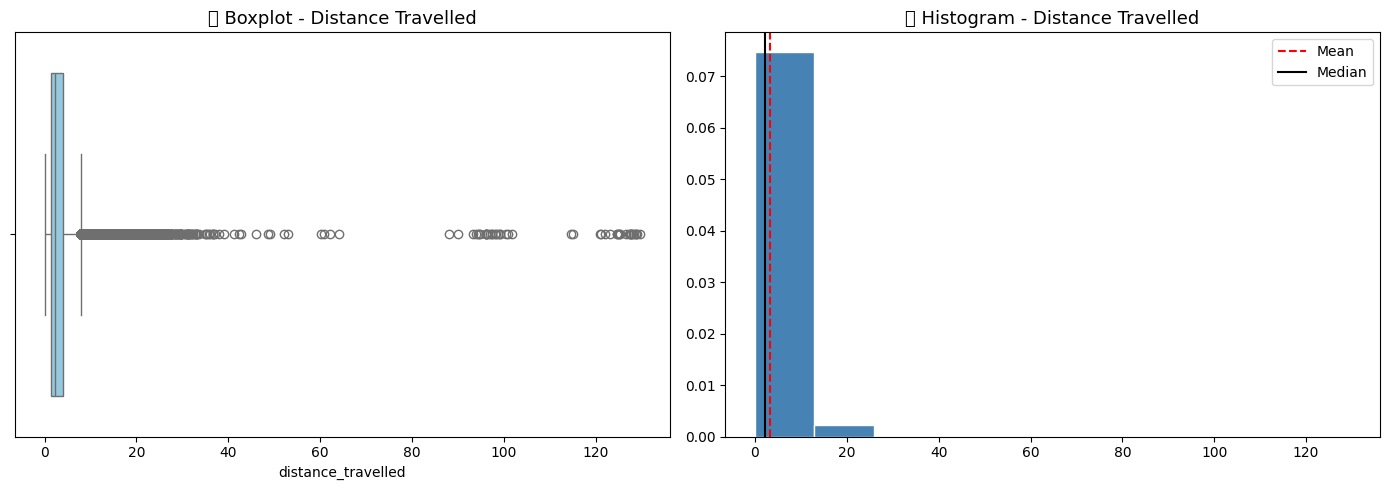

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x=data['distance_travelled'], ax=axes[0], color='skyblue')
axes[0].set_title('📦 Boxplot - Distance Travelled', fontsize=13)

# Histogram
axes[1].hist(data['distance_travelled'], density=True, color='steelblue', edgecolor='white')
axes[1].axvline(data['distance_travelled'].mean(),   color='red',   linestyle='--', label='Mean')
axes[1].axvline(data['distance_travelled'].median(), color='black', linestyle='-',  label='Median')
axes[1].set_title('📈 Histogram - Distance Travelled', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

> **Observations:**
> - Distribution is **negative skewed** (left-skewed)
> - Outliers exist on the left end
> - Mean and Median are relatively close

---
## 📊 Step 9: Univariate Analysis — Categorical Features

### 👥 Passenger Count

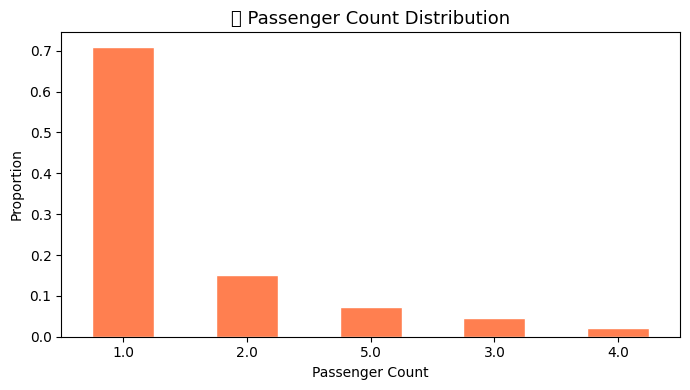

In [15]:
plt.figure(figsize=(7, 4))
data['passenger_count'].value_counts(normalize=True).plot.bar(color='coral', edgecolor='white')
plt.xticks(rotation=0)
plt.title('👥 Passenger Count Distribution', fontsize=13)
plt.ylabel('Proportion')
plt.xlabel('Passenger Count')
plt.tight_layout()
plt.show()

> **Observation:** Almost **70% of trips** had only 1 passenger

### 📅 Day of the Week

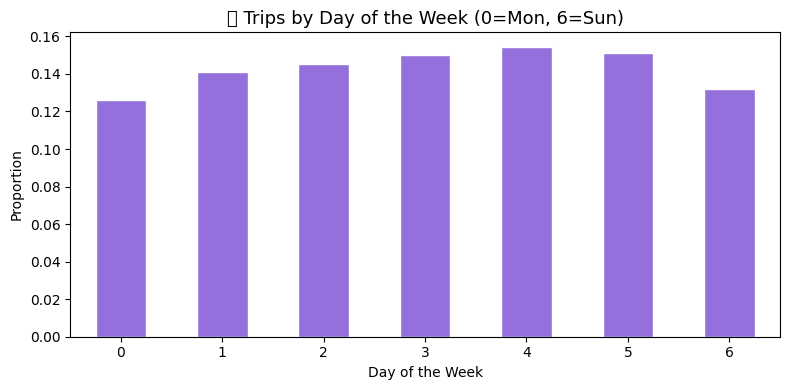

In [16]:
plt.figure(figsize=(8, 4))
data['day_of_the_week'].value_counts(normalize=True).sort_index().plot.bar(color='mediumpurple', edgecolor='white')
plt.xticks(rotation=0)
plt.title('📅 Trips by Day of the Week (0=Mon, 6=Sun)', fontsize=13)
plt.ylabel('Proportion')
plt.xlabel('Day of the Week')
plt.tight_layout()
plt.show()

> **Observation:** **Friday (day 4) and Saturday (day 5)** had the highest number of trips

### ⏰ Pickup Hour

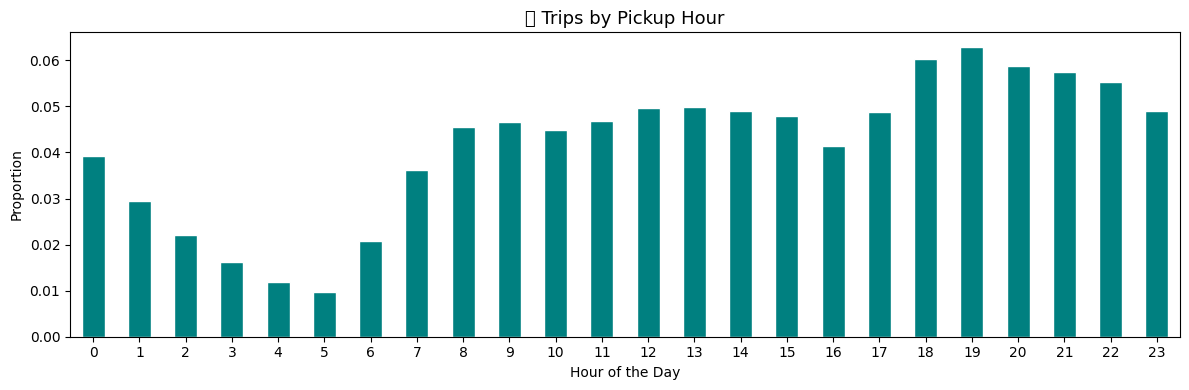

In [17]:
plt.figure(figsize=(12, 4))
data['pickup_hour'].value_counts(normalize=True).sort_index().plot.bar(color='teal', edgecolor='white')
plt.xticks(rotation=0)
plt.title('⏰ Trips by Pickup Hour', fontsize=13)
plt.ylabel('Proportion')
plt.xlabel('Hour of the Day')
plt.tight_layout()
plt.show()

> **Observation:** Trips are **low during 1am–5am** and peak between **7pm–9pm**

---
## 📊 Step 10: Bivariate / Multivariate Analysis

### 📍 Distance vs Fare Amount

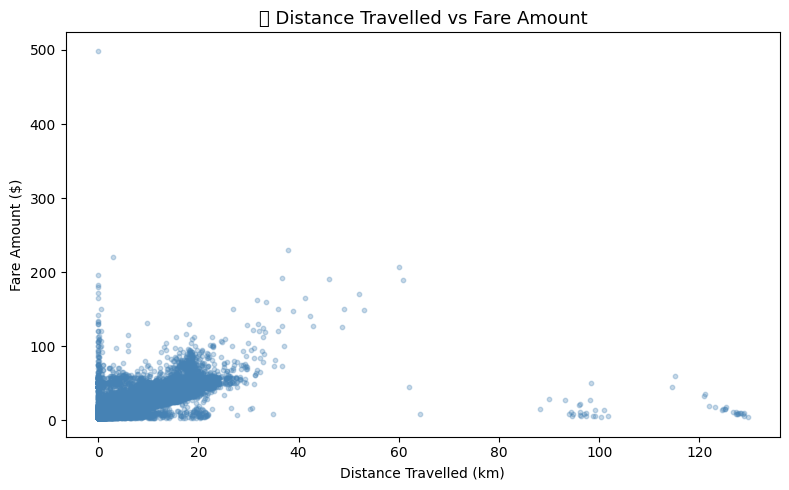

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(data['distance_travelled'], data['fare_amount'], alpha=0.3, color='steelblue', s=10)
plt.title('📍 Distance Travelled vs Fare Amount', fontsize=13)
plt.xlabel('Distance Travelled (km)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

> **Observation:** Generally, as distance increases, fare amount also increases — with a few sporadic inconsistencies

### 📅 Day of Week vs Fare Amount

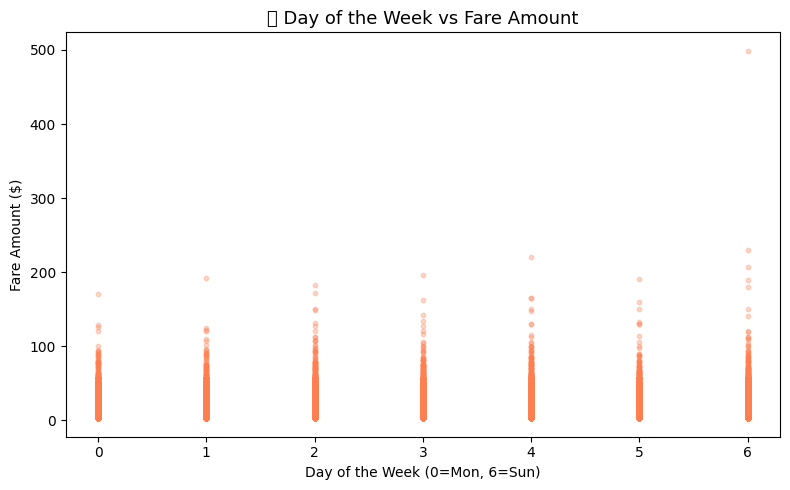

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(data['day_of_the_week'], data['fare_amount'], alpha=0.3, color='coral', s=10)
plt.title('📅 Day of the Week vs Fare Amount', fontsize=13)
plt.xlabel('Day of the Week (0=Mon, 6=Sun)')
plt.ylabel('Fare Amount ($)')
plt.tight_layout()
plt.show()

> **Observation:** Weekend fares tend to be slightly higher than weekday fares

### 📅 Day of Week vs Distance Travelled

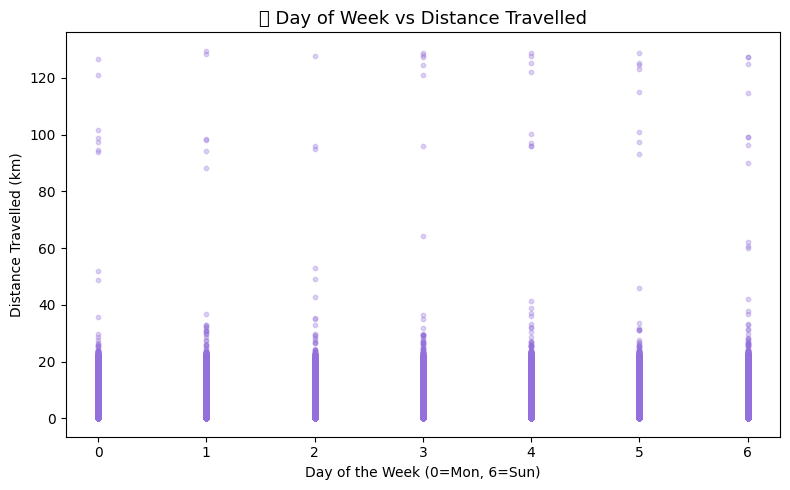

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(data['day_of_the_week'], data['distance_travelled'], alpha=0.3, color='mediumpurple', s=10)
plt.title('📅 Day of Week vs Distance Travelled', fontsize=13)
plt.xlabel('Day of the Week (0=Mon, 6=Sun)')
plt.ylabel('Distance Travelled (km)')
plt.tight_layout()
plt.show()

> **Observation:** No strong relationship between distance and day of week — higher weekend fares are likely due to **peak hours / traffic**, not longer distances

### ⏰ Pickup Hour vs Fare Amount

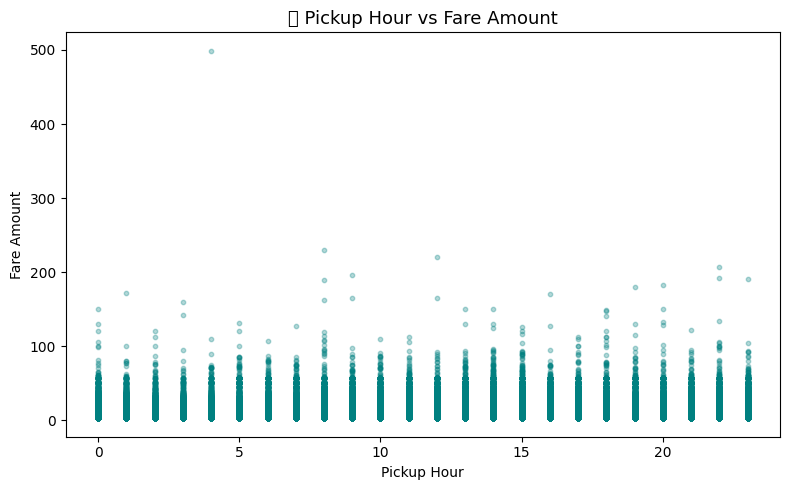

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(data['pickup_hour'], data['fare_amount'], alpha=0.3, color='teal', s=10)
plt.title('⏰ Pickup Hour vs Fare Amount', fontsize=13)
plt.xlabel('Pickup Hour')
plt.ylabel('Fare Amount')
plt.tight_layout()
plt.show()

### ⏰ Pickup Hour vs Distance Travelled

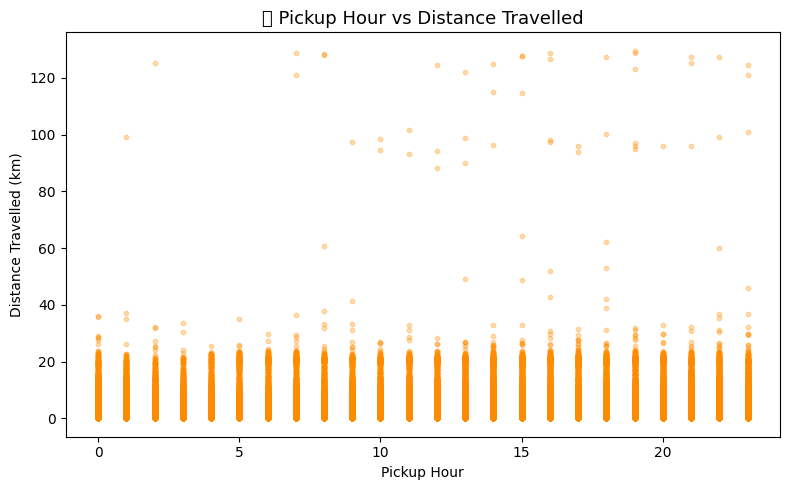

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(data['pickup_hour'], data['distance_travelled'], alpha=0.3, color='darkorange', s=10)
plt.title('⏰ Pickup Hour vs Distance Travelled', fontsize=13)
plt.xlabel('Pickup Hour')
plt.ylabel('Distance Travelled (km)')
plt.tight_layout()
plt.show()

---
## ⚖️ Step 11: Feature Scaling (Standardization)

In [23]:
 
X = data.drop(['fare_amount'], axis=1)
y = data['fare_amount'].values.reshape(-1, 1)

 
std = StandardScaler()
X_std = std.fit_transform(X)
y_std = std.fit_transform(y)

# Train-Test Split (70-30)
X_train, X_test, y_train, y_test = train_test_split(X_std, y_std, test_size=0.3, random_state=42)

print(f"✅ Train size: {X_train.shape}, Test size: {X_test.shape}")

✅ Train size: (132342, 6), Test size: (56719, 6)


---
## 🤖 Step 12: Model 1 — Linear Regression

In [24]:
# Train Linear Regression
LR = LinearRegression()
LR.fit(X_train, y_train)

LR_pred = LR.predict(X_test)

print(f"📌 Training Score : {LR.score(X_train, y_train):.4f}")
print(f"📌 Test Score     : {LR.score(X_test, y_test):.4f}")

📌 Training Score : 0.6536
📌 Test Score     : 0.5782


In [25]:
# Evaluation Metrics
MAE_LR   = metrics.mean_absolute_error(y_test, LR_pred)
MSE_LR   = metrics.mean_squared_error(y_test, LR_pred)
RMSE_LR  = np.sqrt(MSE_LR)
r2_LR    = r2_score(y_test, LR_pred)
Adj_r2_LR = 1 - (1 - r2_LR) * ((len(X_test)-1) / (len(X_test)-len(X_test[0])-1))

print(f"MAE        : {MAE_LR:.4f}")
print(f"MSE        : {MSE_LR:.4f}")
print(f"RMSE       : {RMSE_LR:.4f}")
print(f"R² Score   : {r2_LR:.4f}")
print(f"Adj R²     : {Adj_r2_LR:.4f}")

MAE        : 0.2574
MSE        : 0.4147
RMSE       : 0.6440
R² Score   : 0.5782
Adj R²     : 0.5782


---
## 🌳 Step 13: Model 2 — Decision Tree Regressor

In [27]:
DT = DecisionTreeRegressor(random_state=42)
DT.fit(X_train, y_train)

DT_pred = DT.predict(X_test)

print(f"📌 Training Score : {DT.score(X_train, y_train):.4f}")
print(f"📌 Test Score     : {DT.score(X_test, y_test):.4f}")

📌 Training Score : 1.0000
📌 Test Score     : 0.5572


In [28]:
# Evaluation Metrics
MAE_DT   = metrics.mean_absolute_error(y_test, DT_pred)
MSE_DT   = metrics.mean_squared_error(y_test, DT_pred)
RMSE_DT  = np.sqrt(MSE_DT)
r2_DT    = r2_score(y_test, DT_pred)
Adj_r2_DT = 1 - (1 - r2_DT) * ((len(X_test)-1) / (len(X_test)-len(X_test[0])-1))

print(f"MAE        : {MAE_DT:.4f}")
print(f"MSE        : {MSE_DT:.4f}")
print(f"RMSE       : {RMSE_DT:.4f}")
print(f"R² Score   : {r2_DT:.4f}")
print(f"Adj R²     : {Adj_r2_DT:.4f}")

MAE        : 0.3054
MSE        : 0.4354
RMSE       : 0.6599
R² Score   : 0.5572
Adj R²     : 0.5571


---
## 📋 Step 14: Model Comparison

In [29]:
# Summary comparison table
results = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Decision Tree'],
    'MAE'      : [MAE_LR,    MAE_DT],
    'MSE'      : [MSE_LR,    MSE_DT],
    'RMSE'     : [RMSE_LR,   RMSE_DT],
    'R²'       : [r2_LR,     r2_DT],
    'Adj R²'   : [Adj_r2_LR, Adj_r2_DT]
})

print("📊 Model Performance Comparison:")
results.round(4)

📊 Model Performance Comparison:


,Model,MAE,MSE,RMSE,R²,Adj R²
0,Linear Regression,0.2574,0.4147,0.6440,0.5782,0.5782
1,Decision Tree,0.3054,0.4354,0.6599,0.5572,0.5571


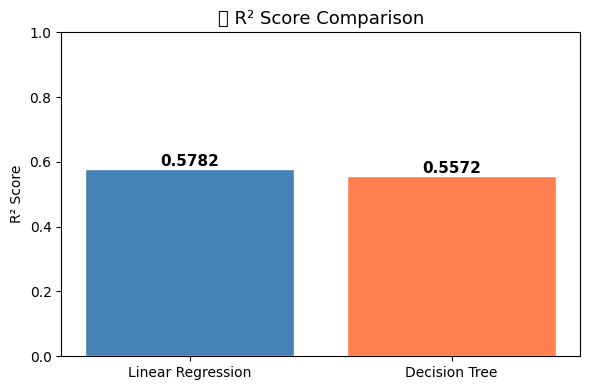


🏆 Best performing model: Linear Regression


In [30]:
# Bar chart comparison of R² scores
plt.figure(figsize=(6, 4))
plt.bar(['Linear Regression', 'Decision Tree'], [r2_LR, r2_DT],
        color=['steelblue', 'coral'], edgecolor='white')
plt.title('📊 R² Score Comparison', fontsize=13)
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate([r2_LR, r2_DT]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = 'Decision Tree' if r2_DT > r2_LR else 'Linear Regression'
print(f"\n🏆 Best performing model: {best_model}")